Batch 1:
Variance PC1: 0.5776
Variance PC2: 0.2374
Total variance PC1+PC2: 0.8150
Komponen untuk 95% variance: 6


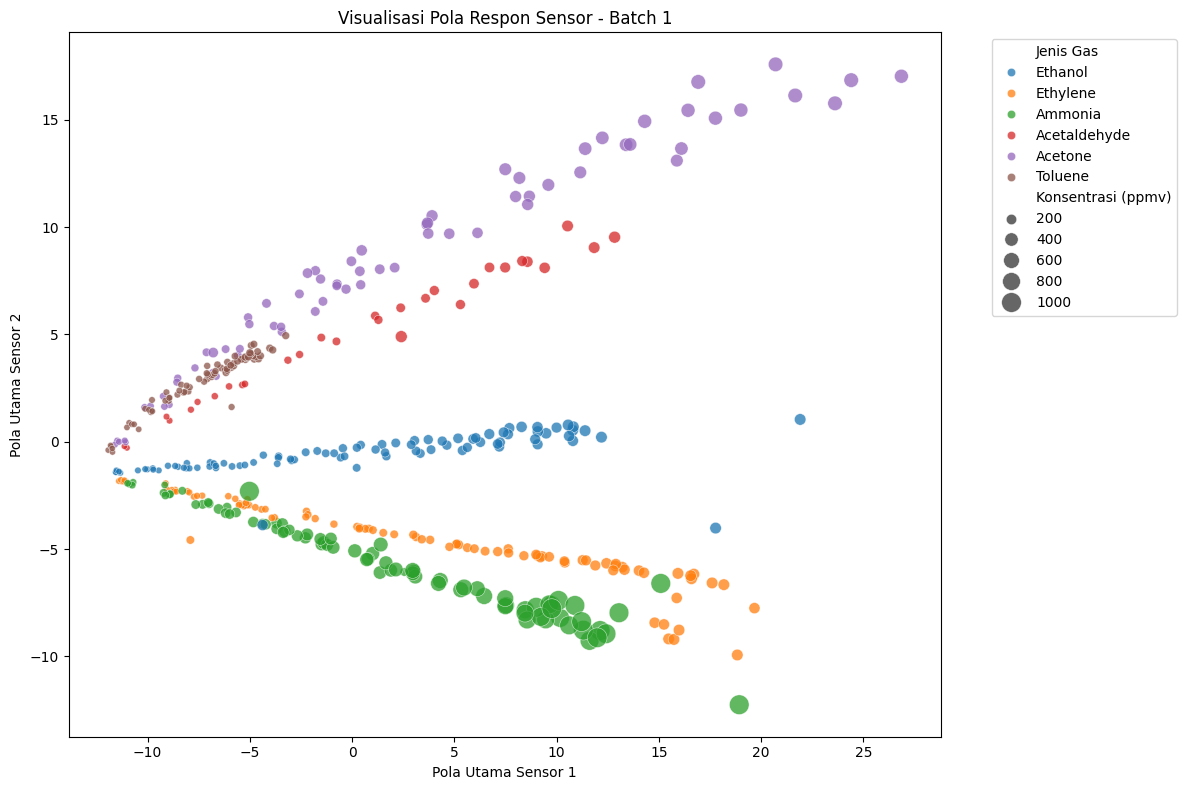

✅ Batch 1 selesai divisualisasikan
Jumlah data: 445
--------------------------------------------------
Batch 2:
Variance PC1: 0.4221
Variance PC2: 0.2324
Total variance PC1+PC2: 0.6545
Komponen untuk 95% variance: 11


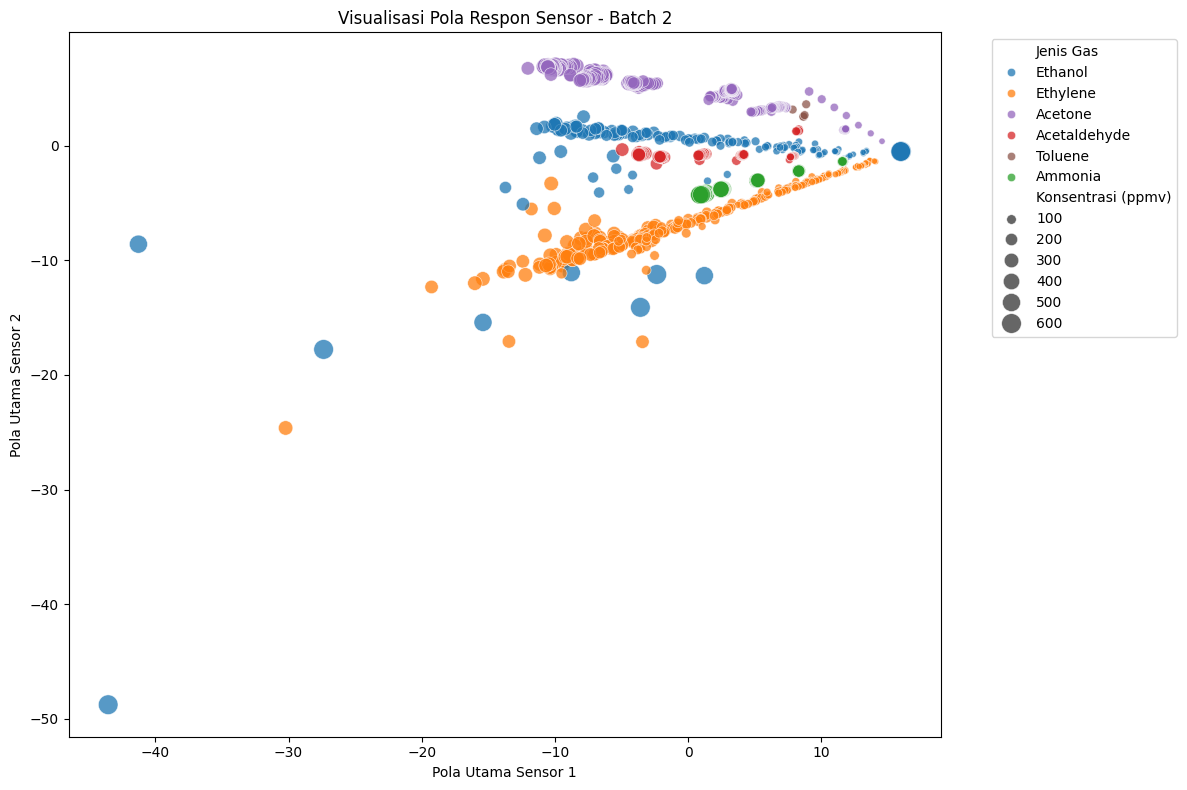

✅ Batch 2 selesai divisualisasikan
Jumlah data: 1244
--------------------------------------------------
Batch 3:
Variance PC1: 0.5733
Variance PC2: 0.2549
Total variance PC1+PC2: 0.8282
Komponen untuk 95% variance: 5


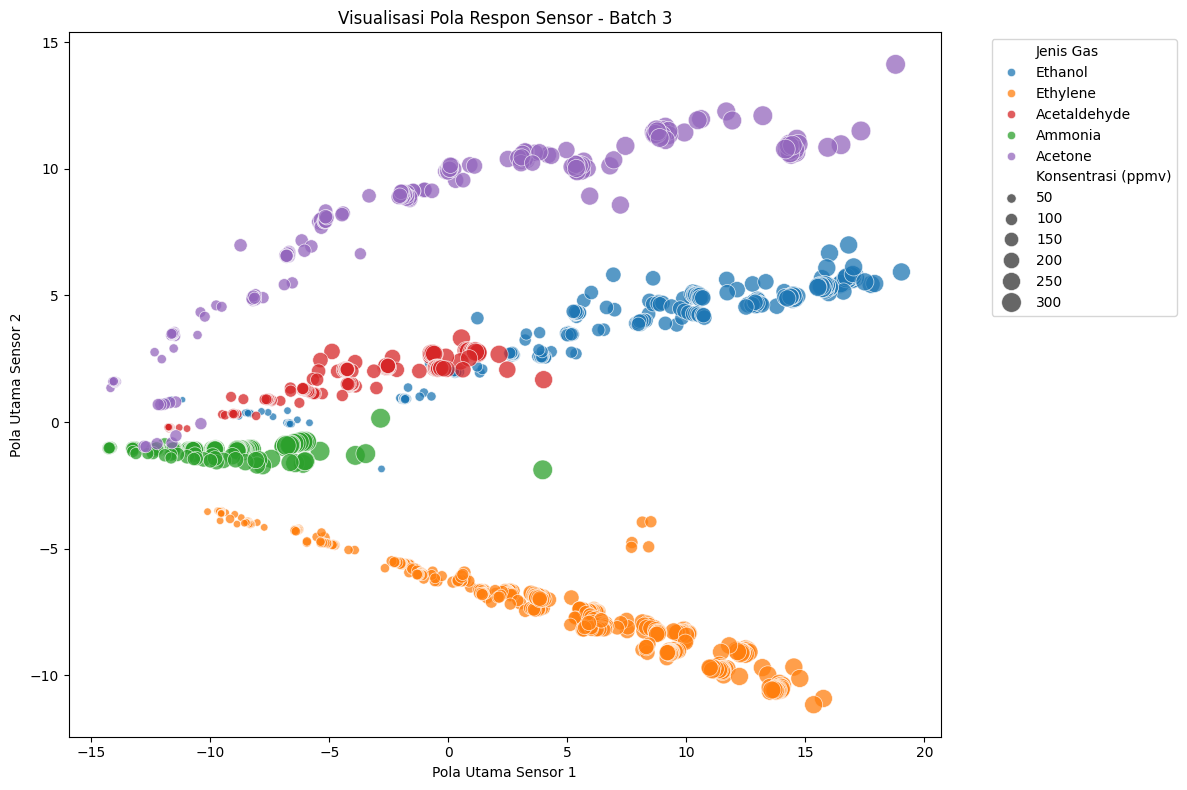

✅ Batch 3 selesai divisualisasikan
Jumlah data: 1586
--------------------------------------------------
Batch 4:
Variance PC1: 0.4372
Variance PC2: 0.2117
Total variance PC1+PC2: 0.6489
Komponen untuk 95% variance: 8


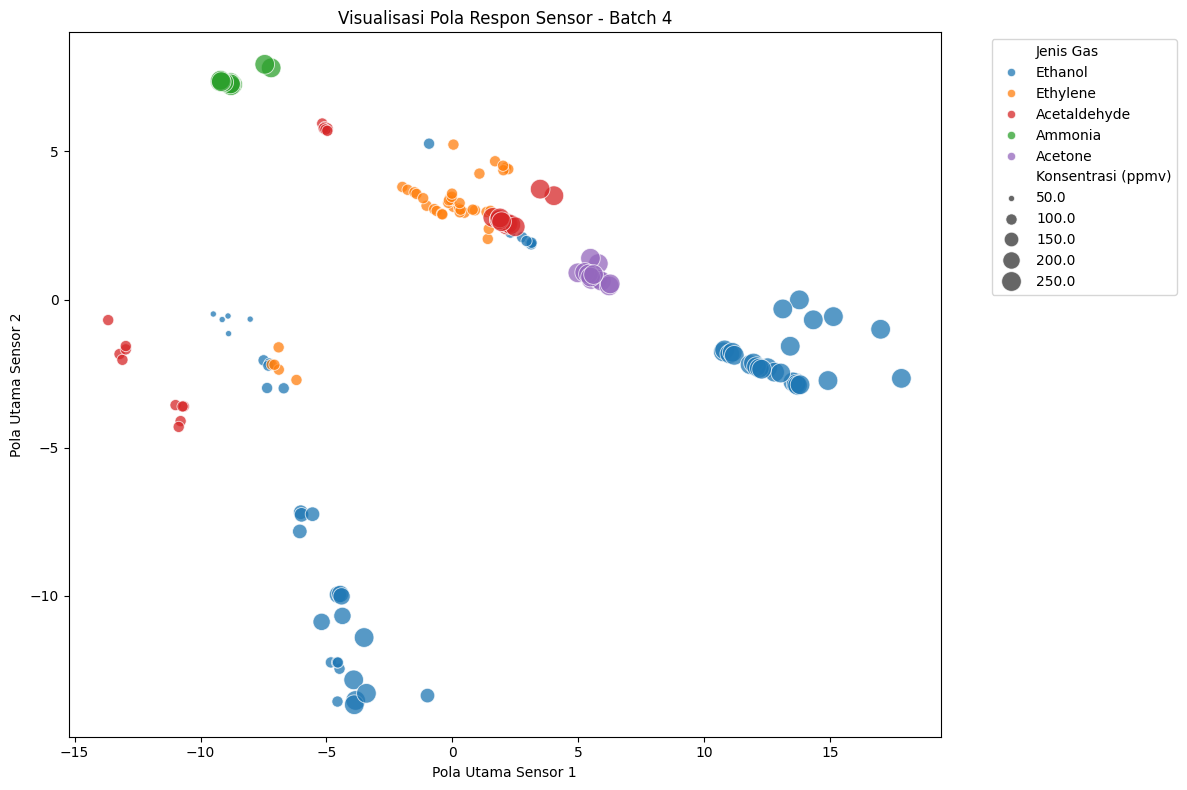

✅ Batch 4 selesai divisualisasikan
Jumlah data: 161
--------------------------------------------------
Batch 5:
Variance PC1: 0.5729
Variance PC2: 0.2622
Total variance PC1+PC2: 0.8351
Komponen untuk 95% variance: 5


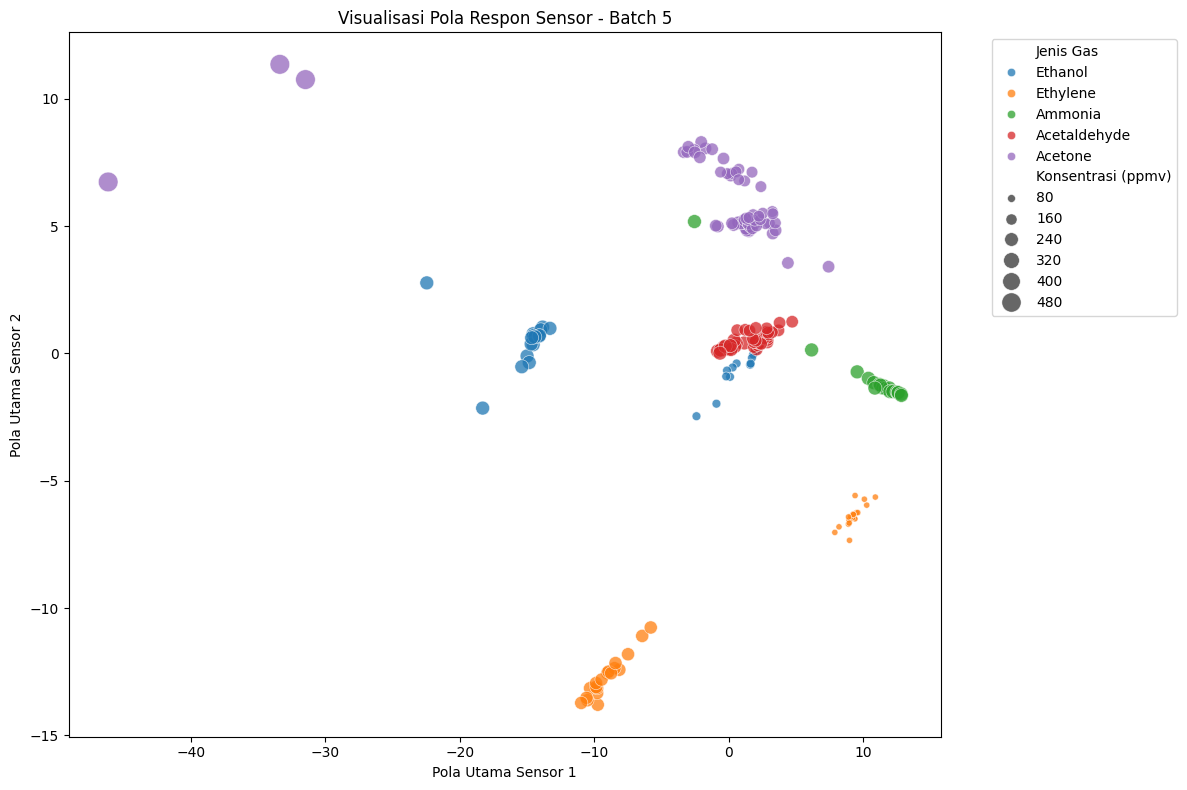

✅ Batch 5 selesai divisualisasikan
Jumlah data: 197
--------------------------------------------------
Batch 6:
Variance PC1: 0.6254
Variance PC2: 0.2254
Total variance PC1+PC2: 0.8508
Komponen untuk 95% variance: 5


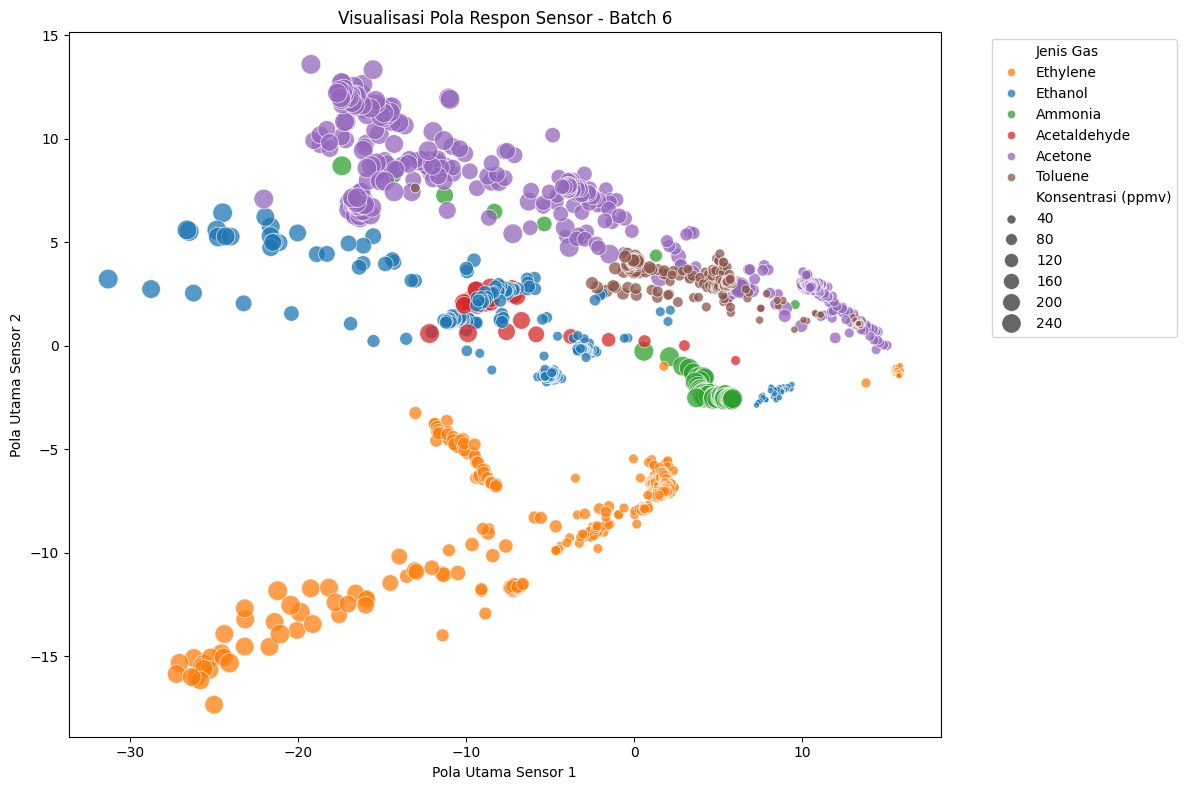

✅ Batch 6 selesai divisualisasikan
Jumlah data: 2300
--------------------------------------------------
Batch 7:
Variance PC1: 0.6998
Variance PC2: 0.1643
Total variance PC1+PC2: 0.8642
Komponen untuk 95% variance: 5


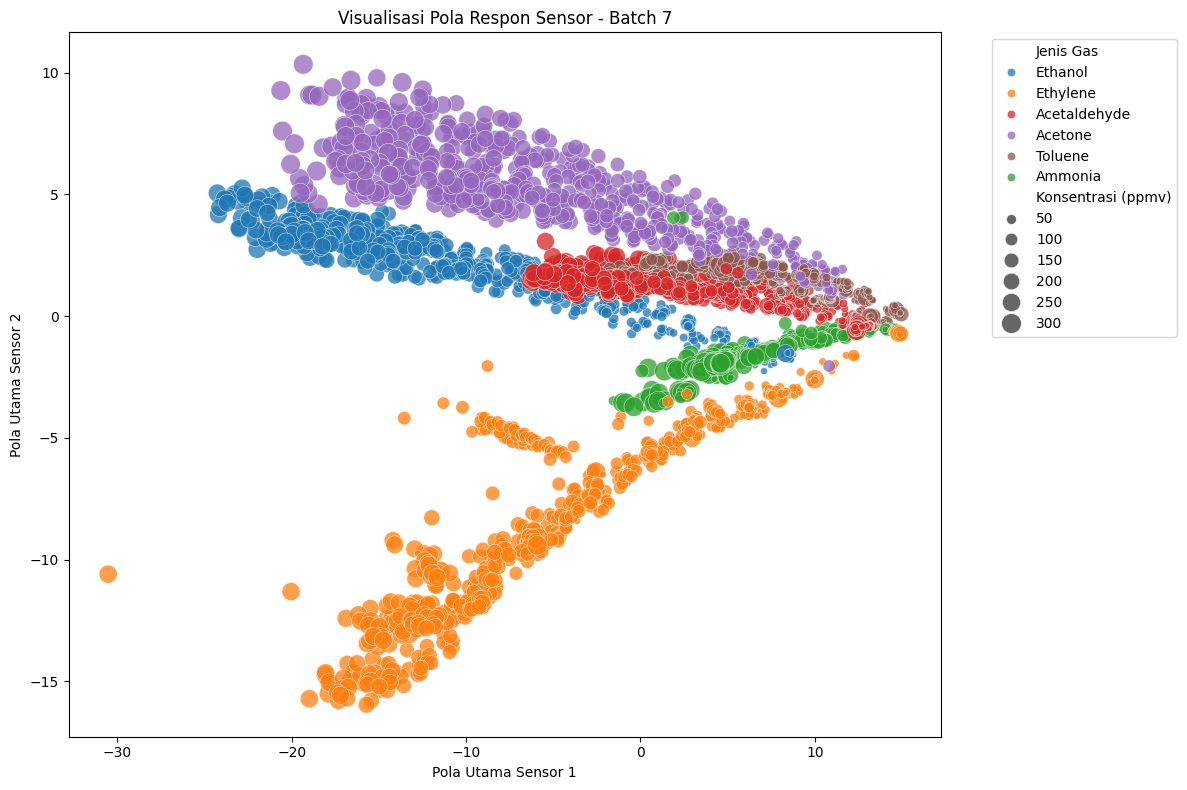

✅ Batch 7 selesai divisualisasikan
Jumlah data: 3613
--------------------------------------------------
Batch 8:
Variance PC1: 0.6054
Variance PC2: 0.1842
Total variance PC1+PC2: 0.7896
Komponen untuk 95% variance: 7


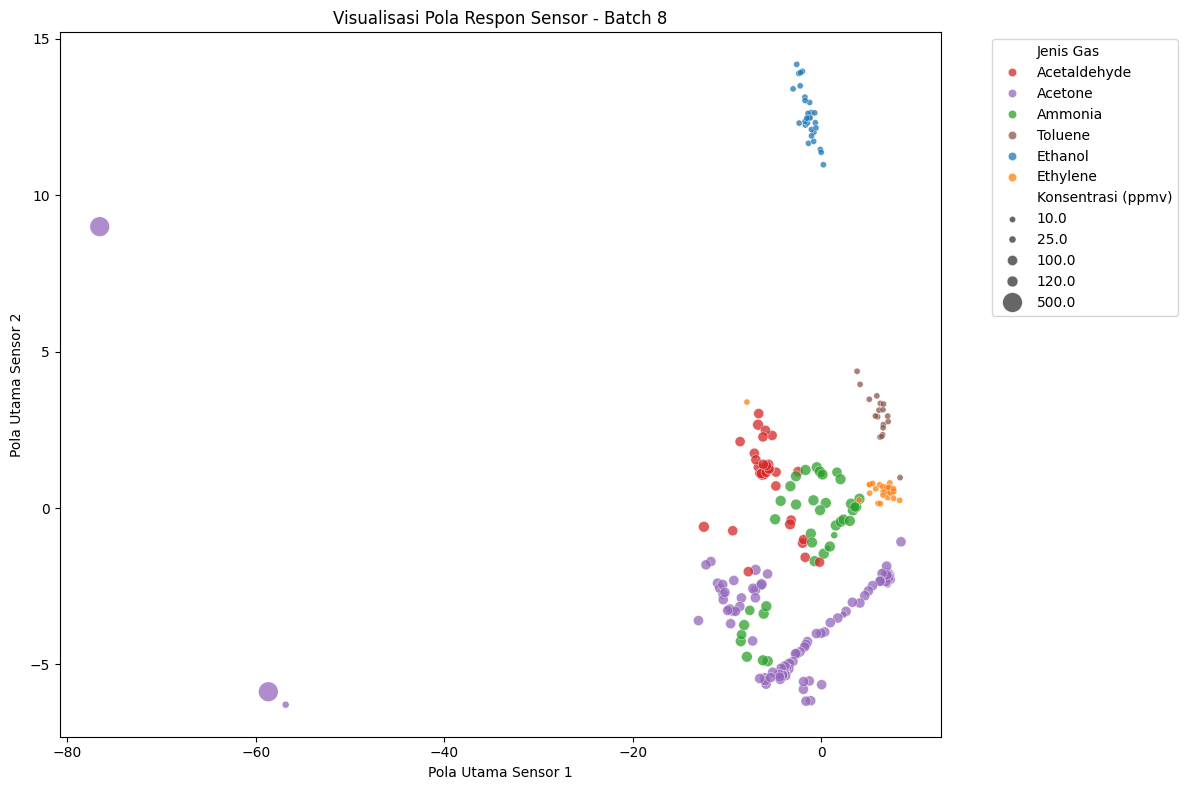

✅ Batch 8 selesai divisualisasikan
Jumlah data: 294
--------------------------------------------------
Batch 9:
Variance PC1: 0.4241
Variance PC2: 0.2826
Total variance PC1+PC2: 0.7067
Komponen untuk 95% variance: 8


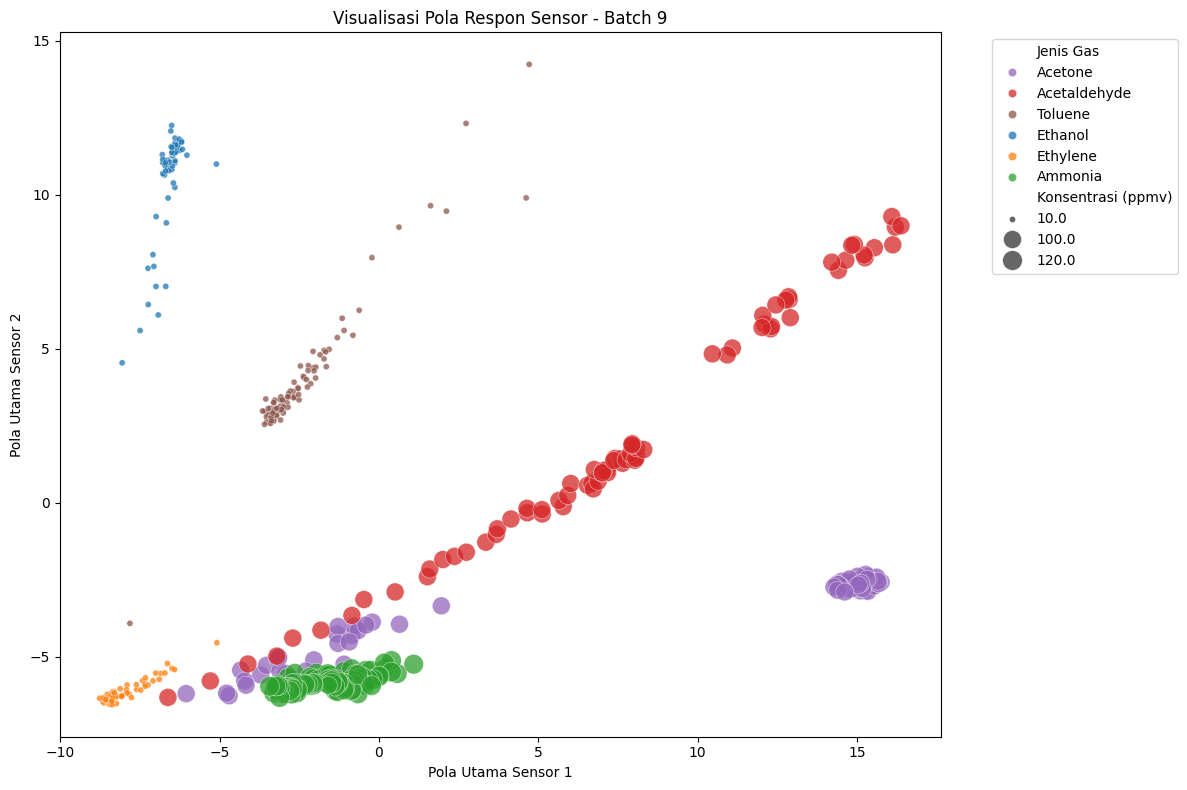

✅ Batch 9 selesai divisualisasikan
Jumlah data: 470
--------------------------------------------------
Batch 10:
Variance PC1: 0.7697
Variance PC2: 0.0865
Total variance PC1+PC2: 0.8562
Komponen untuk 95% variance: 5


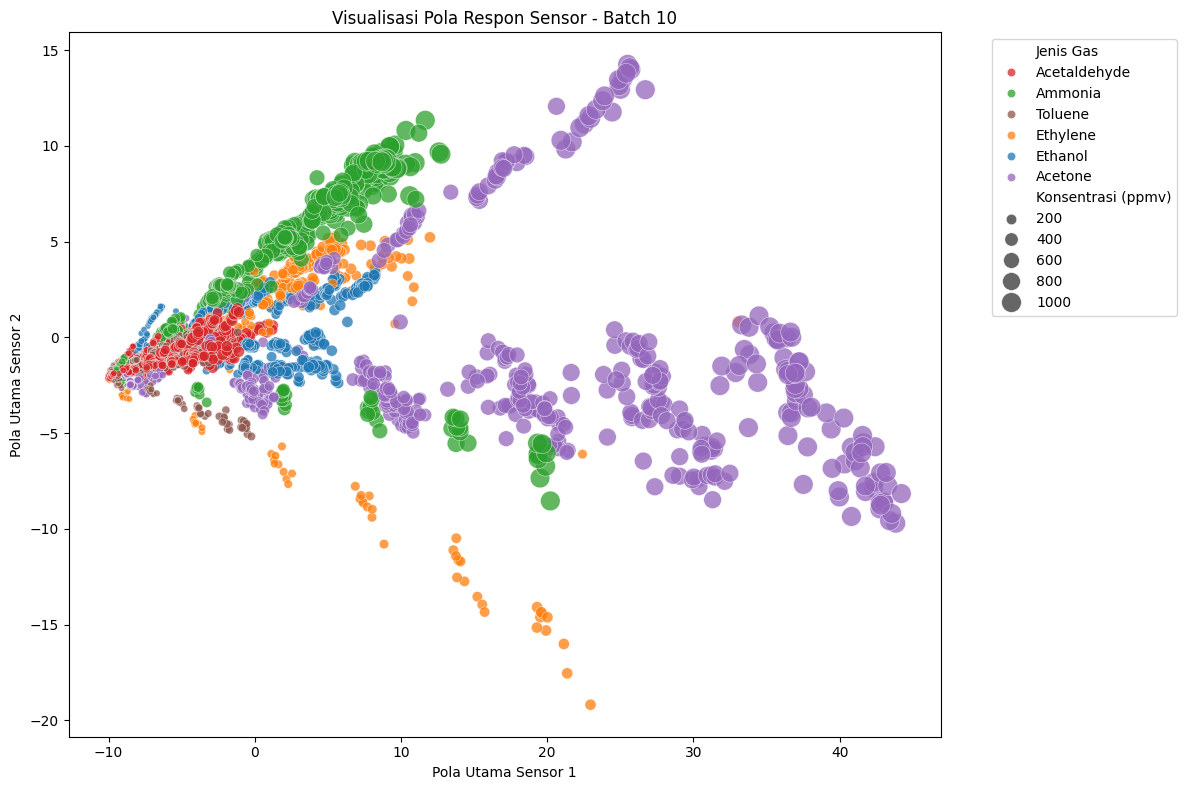

✅ Batch 10 selesai divisualisasikan
Jumlah data: 3600
--------------------------------------------------


In [ ]:
#visualisasi PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

gas_names = {
    1: 'Ethanol',
    2: 'Ethylene',
    3: 'Ammonia',
    4: 'Acetaldehyde',
    5: 'Acetone',
    6: 'Toluene'
}

gas_palette = {
    'Ethanol': '#1f77b4',
    'Ethylene': '#ff7f0e',
    'Ammonia': '#2ca02c',
    'Acetaldehyde': '#d62728',
    'Acetone': '#9467bd',
    'Toluene': '#8c564b'
}

for batch_num in range(1, 11):

    file_path = f'data/batch{batch_num}_clean.csv'

    if not os.path.exists(file_path):
        print(f'❌ {file_path} tidak ditemukan')
        continue

    df = pd.read_csv(file_path)

    X = df.drop(['label', 'concentration_ppmv'], axis=1)
    y = df['label'].map(gas_names)
    concentration = df['concentration_ppmv']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca_full = PCA()
    pca_full.fit(X_scaled)

    cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
    n_components_95 = next(i+1 for i, v in enumerate(cumulative_variance) if v >= 0.95)

    print(f'Batch {batch_num}:')
    print(f'Variance PC1: {pca_full.explained_variance_ratio_[0]:.4f}')
    print(f'Variance PC2: {pca_full.explained_variance_ratio_[1]:.4f}')
    print(f'Total variance PC1+PC2: {cumulative_variance[1]:.4f}')
    print(f'Komponen untuk 95% variance: {n_components_95}')


    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        'Pola Utama Sensor 1': X_pca[:, 0],
        'Pola Utama Sensor 2': X_pca[:, 1],
        'Jenis Gas': y.values,
        'Konsentrasi (ppmv)': concentration.values
    })

    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        data=pca_df,
        x='Pola Utama Sensor 1',
        y='Pola Utama Sensor 2',
        hue='Jenis Gas',
        palette=gas_palette,
        size='Konsentrasi (ppmv)',
        sizes=(20, 200),
        alpha=0.75
    )

    plt.title(f'Visualisasi Pola Respon Sensor - Batch {batch_num}')
    plt.xlabel('Pola Utama Sensor 1')
    plt.ylabel('Pola Utama Sensor 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    print(f'✅ Batch {batch_num} selesai divisualisasikan')
    print('Jumlah data:', df.shape[0])
    print('-' * 50)